 ## Lab - Week 10 - Dropout

### Ways to reduce overfitting in neural networks
 - Getting more training data
 - Reducing the capacity of the network (last week's lab)
 - Adding weight regularization (last week's lab)
 - Adding dropout (the subject for this week)
 - Using transfer learning

### Typical training and validation loss over time
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*0VWDpLIRcMTssDf-zyOR4w.jpeg)

## Dropout Regularization

**Dropout** is a regularization technique that involves randomly "dropping out" (setting to zero) a subset of a layer's output features during training.

For example, if a layer would normally return the vector `[0.2, 0.5, 1.3, 0.8, 1.1]` for a specific input, applying dropout might result in `[0, 0.5, 1.3, 0, 1.1]`. The **dropout rate** defines the fraction of features zeroed out and typically ranges between 0.2 and 0.5.

At test time, no units are dropped. To compensate for the fact that all neurons are now active (unlike during training), the layer’s output values are scaled down by a factor equal to the dropout rate. This ensures that the expected sum of the inputs to the next layer remains consistent between training and inference.


![dropout](https://cdn-images-1.medium.com/max/1600/1*iWQzxhVlvadk6VAJjsgXgg.png)

In Keras you can introduce dropout in a network via the `Dropout` layer, which gets applied to the output of layer right before it, e.g.:
```python
model.add(layers.Dropout(0.5))
```

### Part 1: Load and Prepare Data - IMDB dataset

In [1]:
from keras import models
from keras import layers
from keras.datasets import imdb
import numpy as np

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
      for j in sequence:
        results[i, j] += 1
    return results

# Our vectorized training data
x_train = vectorize_sequences(train_data)
# Our vectorized test data
x_test = vectorize_sequences(test_data)
# Our vectorized labels
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

**As a routine, perform a sanity check on the dataset to understand the shape of the train and test inputs and outputs, and print out a sample of the data.**

In [2]:
#TODO
#your code here


print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (25000, 10000)
y_train shape: (25000,)


### Part 2: Build a Simple Neural Network Model
Objective: Create a basic neural network model using Keras.

**Questions**
- What type of classification problem are we solving?
- How many neurons should there be in the output layer?
- What should be the activation function of the output layer?
- What loss function should be used?
- What activation function should be used on the hidden layers?


Build a sequential model with one dense layer with 8 units and train it for 20 epochs.

Complete the code below:

In [3]:
# TODO fix this code
  # Add a single hidden layer with 8 units and proper activation
  # Compile the model with an appropriate optimizer, loss function, and evaluation metric.
  # Show the summary of the model

model = models.Sequential()
model.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Train the model
hist_a = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

# Evaluate the model
evaluation_results = model.evaluate(x_test, y_test)
print("Test accuracy:", evaluation_results[1])

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.7974 - loss: 0.5144 - val_accuracy: 0.8540 - val_loss: 0.4282
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.8876 - loss: 0.3536 - val_accuracy: 0.8657 - val_loss: 0.3661
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.9046 - loss: 0.2876 - val_accuracy: 0.8853 - val_loss: 0.3146
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.9162 - loss: 0.2501 - val_accuracy: 0.8896 - val_loss: 0.2947
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.9245 - loss: 0.2239 - val_accuracy: 0.8900 - val_loss: 0.2864
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9316 - loss: 0.2053 - val_accuracy: 0.8882 - val_loss: 0.2885
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9359 - loss: 0.1899 - val_accuracy: 0.8892 - val_loss: 0.2835
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9405 - loss: 0.1785 - val_accuracy: 0.8880 - 

### Part 3: Visualize Training and Validation Performance

The function below can be used later to plot the loss and accuracy from the model training history

In [5]:
# Helper function

import matplotlib.pyplot as plt
# colors will be used to plot the different models below
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

def plot_history(history, color='blue', prefix=""):
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)

    # Make a figure with two subplots side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)

    # Plot the loss
    plt.plot(epochs, loss_values, "o",  color=color, label=prefix + " Training loss")
    plt.plot(epochs, val_loss_values, color=color, label=prefix + " Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(framealpha=0.5)
    plt.grid()

    # Plot the accuracy
    plt.subplot(1, 2, 2)
    acc_values = history_dict['accuracy']
    val_acc_values = history_dict['val_accuracy']
    # Skip plotting the training accuracy, it makes the plot harder to read
    # plt.plot(epochs, acc_values, "o", color=color , label=prefix + " Training accuracy")
    plt.plot(epochs, val_acc_values, color=color, label=prefix + " Validation accuracy")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend(framealpha=0.5)
    plt.grid()

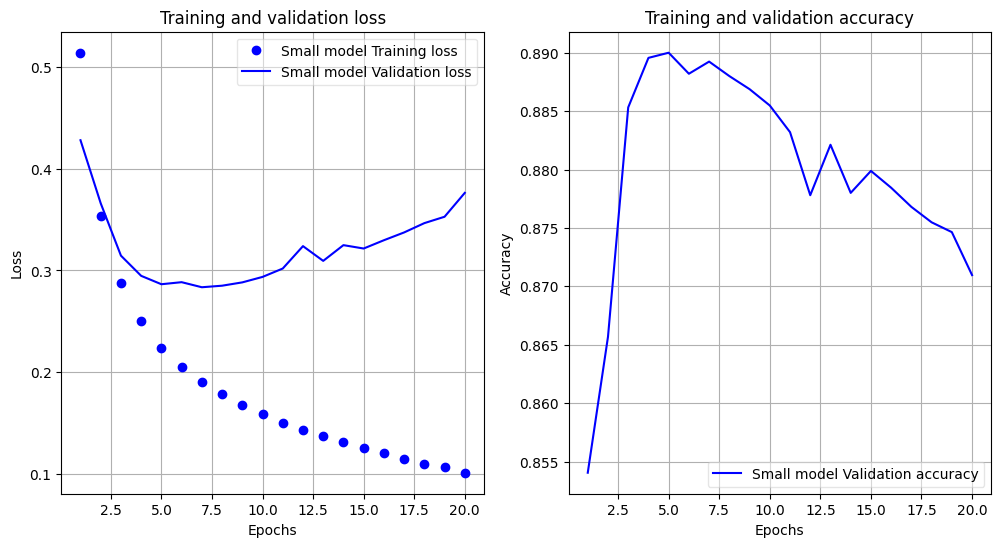

In [6]:
# Using the plotting function

plot_history(hist_a, color='blue', prefix="Small model")

### Part 4: Add Dropout Regularization
Objective: Experiment with dropout layers in the model.

**Instructions:**
1. Add another hidden layer with 8 units
1. Add dropout layers after each hidden layer with a dropout rate of 0.3.
1. Compile the model.
1. Train the model and observe the changes in accuracy.

Complete the code below:

In [7]:
# TODO: Build a model with 30% Dropout
drp_model = models.Sequential()

drp_model.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
drp_model.add(layers.Dropout(0.3))

drp_model.add(layers.Dense(8, activation='relu'))
drp_model.add(layers.Dropout(0.3))

drp_model.add(layers.Dense(1, activation='sigmoid'))

drp_model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

drp_model.summary()

drp_history = drp_model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8)              │        80,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,089 (312.85 KB)

 Trainable params: 80,089 (312.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 86ms/step - accuracy: 0.6488 - loss: 0.6227 - val_accuracy: 0.8355 - val_loss: 0.5375
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7578 - loss: 0.5126 - val_accuracy: 0.8708 - val_loss: 0.4354
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8109 - loss: 0.4525 - val_accuracy: 0.8709 - val_loss: 0.3845
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8413 - loss: 0.3982 - val_accuracy: 0.8861 - val_loss: 0.3316
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8696 - loss: 0.3468 - val_accuracy: 0.8869 - val_loss: 0.3030
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8916 - loss: 0.3053 - val_accuracy: 0.8804 - val_loss: 0.3027
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.9055 - loss: 0.2714 - val_accuracy: 0.8870 - val_loss: 0.2832
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9146 - loss: 0.2471 - val_accuracy: 0.8884 - v

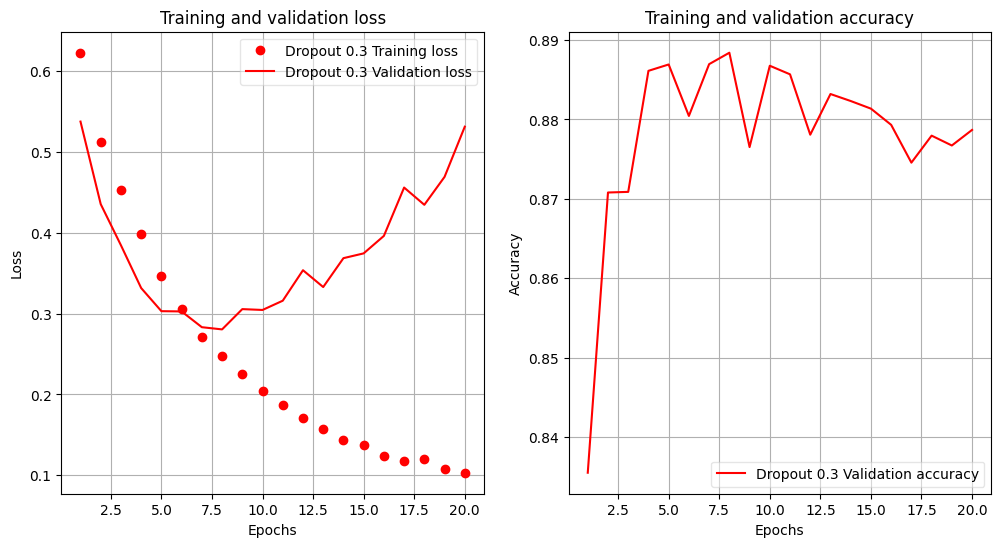

In [8]:
# Plot training history
plot_history(drp_history, color='red', prefix="Dropout 0.3")

### Part 5: Test Different Dropout Rates
Objective: Compare the model's performance with varying dropout rates.

**Instructions:**
1. Write a loop to create and train models with dropout rates of `[0, 0.2, 0.3, 0.4, 0.5]`.
2. For each model, record the history to plot it later


Complete the code below:

In [9]:
# TODO: try different dropout rates

rates = [0, 0.2, 0.3, 0.4, 0.5]
colors = ['blue', 'green', 'red', 'purple', 'orange']
hists = []

for rate in rates:
    model = models.Sequential()

    model.add(layers.Dense(8, activation='relu', input_shape=(10000,)))

    if rate > 0:
        model.add(layers.Dropout(rate))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='rmsprop',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    hist = model.fit(x_train, y_train, epochs=20, batch_size=512, validation_data=(x_test, y_test))
    hists.append(hist)



Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - accuracy: 0.7840 - loss: 0.5343 - val_accuracy: 0.8567 - val_loss: 0.4370
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.8842 - loss: 0.3621 - val_accuracy: 0.8792 - val_loss: 0.3481
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9056 - loss: 0.2879 - val_accuracy: 0.8848 - val_loss: 0.3148
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9177 - loss: 0.2470 - val_accuracy: 0.8891 - val_loss: 0.2973
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9261 - loss: 0.2199 - val_accuracy: 0.8894 - val_loss: 0.2868
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9322 - loss: 0.2016 - val_accuracy: 0.8803 - val_loss: 0.3089
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9371 - loss: 0.1867 - val_accuracy: 0.8868 - val_loss: 0.2896
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9416 - loss: 0.1745 - val_accuracy: 0.8865 - v

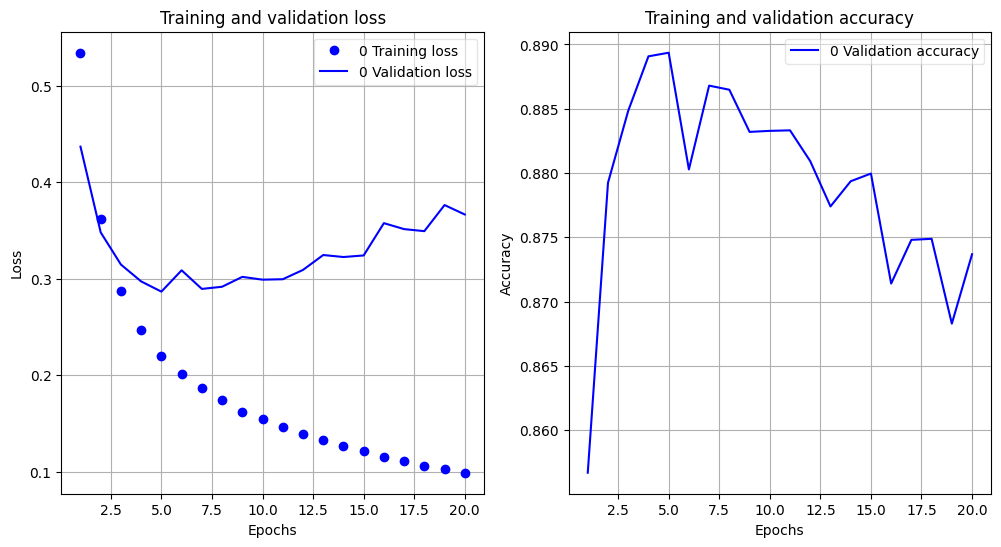

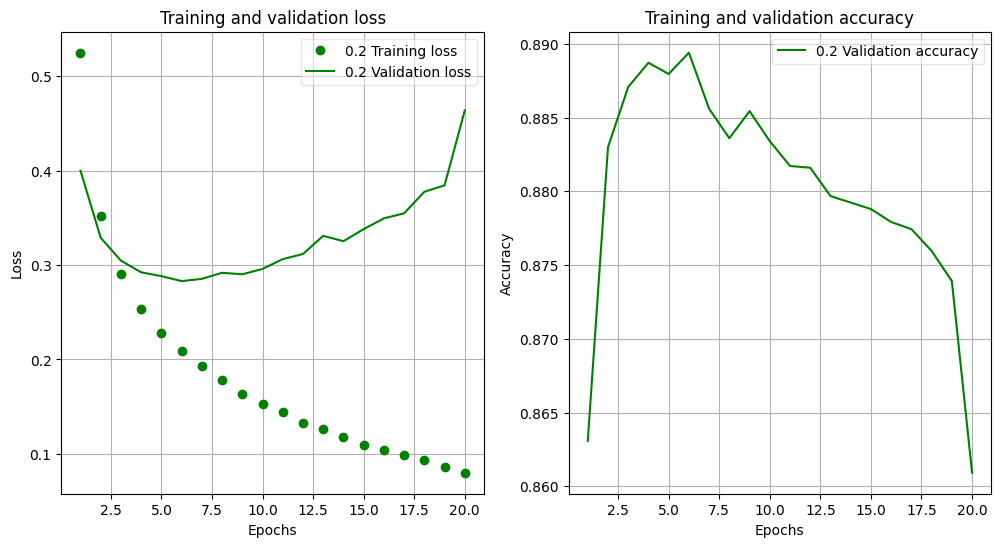

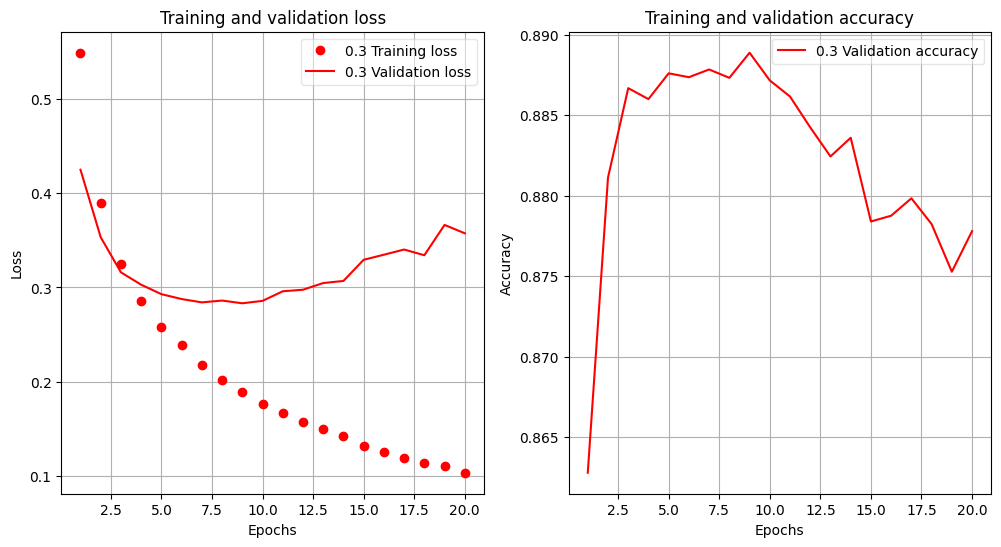

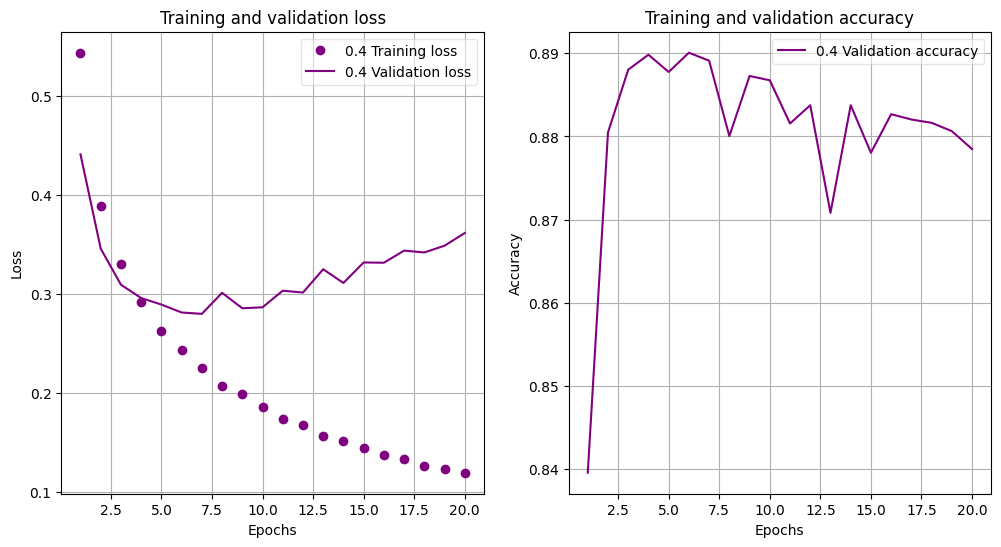

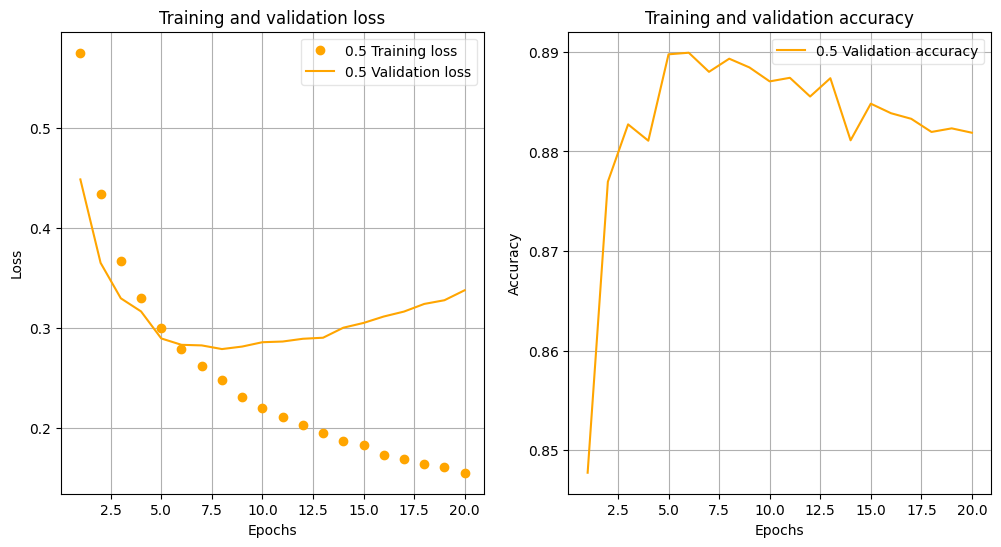

In [10]:
for i, hist in enumerate(hists):
    plot_history(hist, colors[i], prefix=str(rates[i]))

### Part 6: Experiment with dropout location
Objective: Compare the model's performance with dropout placed after different layers

**Instructions:**
Create 3 models with a single dropout "layer" placed:
1. Before the first dense layer only
2. After the first dense layer only
3. After the second dense layer only



Complete the code below:

In [11]:
hists_b = [] #append the training history of 3 cases mentioned above
rate = 0.4
#TODO: your code here


# Case 1
model1 = models.Sequential()
model1.add(layers.Dropout(rate, input_shape=(10000,)))
model1.add(layers.Dense(8, activation='relu'))
model1.add(layers.Dense(1, activation='sigmoid'))

# Case 2
model2 = models.Sequential()
model2.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
model2.add(layers.Dropout(rate))
model2.add(layers.Dense(1, activation='sigmoid'))

# Case 3
model3 = models.Sequential()
model3.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
model3.add(layers.Dense(8, activation='relu'))
model3.add(layers.Dropout(rate))
model3.add(layers.Dense(1, activation='sigmoid'))

models_list = [model1, model2, model3]

for m in models_list:
    m.compile(
        optimizer='rmsprop',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    hist = m.fit(
        x_train,
        y_train,
        epochs=20,
        batch_size=512,
        validation_split=0.2,
        verbose=0
    )

    hists_b.append(hist)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


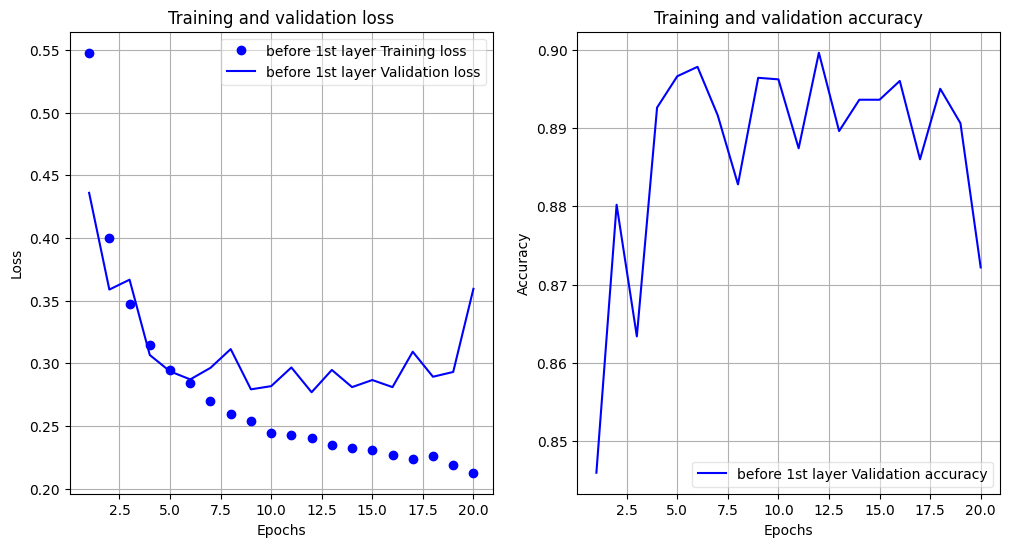

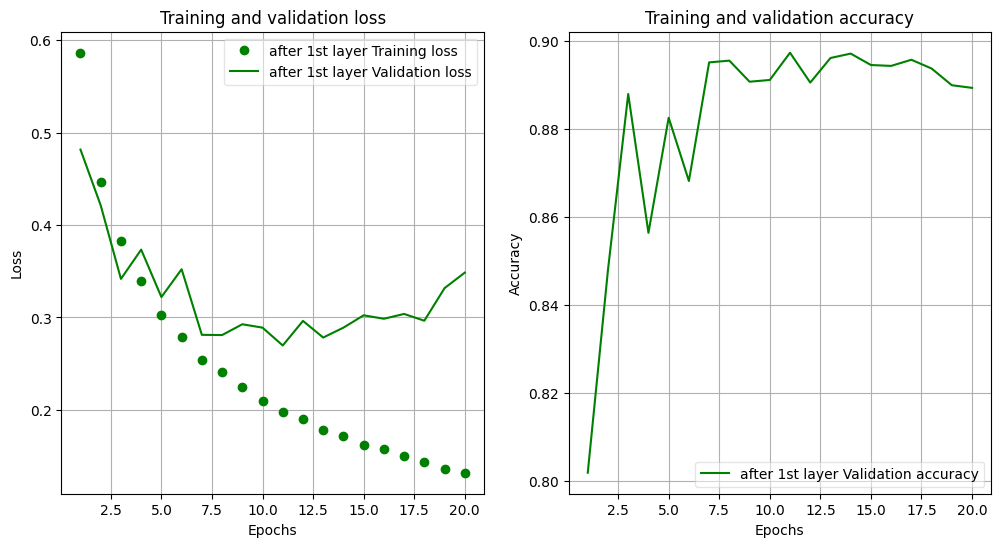

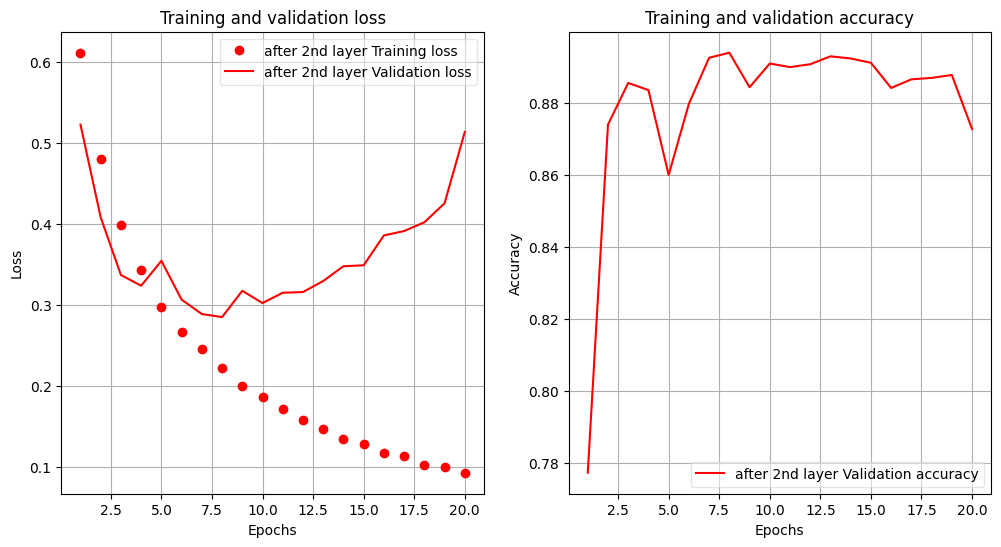

In [12]:
prefixes = ['before 1st layer', 'after 1st layer', 'after 2nd layer']
for i, hist in enumerate(hists_b):
    plot_history(hist, colors[i], prefix=prefixes[i])